# Presentation

```{important} AI Disclosure
The written content in this report was drafted by Jenny Lee and refined using Generative AI for clarity and grammar. All ideas, analysis decisions, and interpretations are original. The prompt used throughout was: *"Refine my words."*
```

In [10]:
import pandas as pd
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
import time
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import requests
from PIL import Image
import matplotlib.image as mpimg
from io import BytesIO

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

## Review Data

In [2]:
df = pd.read_csv("../data/box_office_data_analysis.csv")
df

,id,type,primaryTitle,originalTitle,primaryImage,startYear,runtimeSeconds,genres,rating,plot,worldwideGross,worldwideGrossCurrency,productionBudget,productionBudgetCurrency,totalStarMeter,genres_list,grossBudgetRatio,grossBudgetRatio_log,genres_parsed,cluster
0,tt12042730,movie,Project Hail Mary,Project Hail Mary,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,9360.0,"['Adventure', 'Comedy', 'Sci-Fi']","{'aggregateRating': 8.4, 'voteCount': 178625}",A science teacher wakes up alone on a spaceshi...,433030505.0,USD,200000000.0,USD,37,"['Adventure', 'Comedy', 'Sci-Fi']",2.165153,0.772491,"['Adventure', 'Comedy', 'Sci-Fi']",0
1,tt28650488,movie,The Super Mario Galaxy Movie,The Super Mario Galaxy Movie,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,5880.0,"['Animation', 'Adventure', 'Comedy', 'Family',...","{'aggregateRating': 6.5, 'voteCount': 25522}","Mario ventures into space, exploring cosmic wo...",437751829.0,USD,110000000.0,USD,66,"['Animation', 'Adventure', 'Comedy', 'Family',...",3.979562,1.381172,"['Animation', 'Adventure', 'Comedy', 'Family',...",0
2,tt32430579,movie,Crime 101,Crime 101,{'url': 'https://m.media-amazon.com/images/M/M...,2026.0,8400.0,"['Crime', 'Drama', 'Thriller']","{'aggregateRating': 6.8, 'voteCount': 48321}","An elusive thief, eyeing his final score, enco...",72559167.0,USD,90000000.0,USD,49,"['Crime', 'Drama', 'Thriller']",0.806213,-0.215407,"['Crime', 'Drama', 'Thriller']",0
3,tt27543632,movie,The Housemaid,The Housemaid,{'url': 'https://m.media-amazon.com/images/M/M...,2025.0,7860.0,"['Drama', 'Mystery', 'Thriller']","{'aggregateRating': 6.8, 'voteCount': 128853}",A struggling young woman is relieved by the ch...,399318859.0,USD,35000000.0,USD,31,"['Drama', 'Mystery', 'Thriller']",11.409110,2.434412,"['Drama', 'Mystery', 'Thriller']",0
4,tt33244668,movie,Anaconda,Anaconda,{'url': 'https://m.media-amazon.com/images/M/M...,2025.0,5940.0,"['Action', 'Adventure', 'Comedy']","{'aggregateRating': 5.6, 'voteCount': 52429}",A group of friends are going through a mid-lif...,134974943.0,USD,45000000.0,USD,37,"['Action', 'Adventure', 'Comedy']",2.999443,1.098427,"['Action', 'Adventure', 'Comedy']",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
738,tt0119081,movie,Event Horizon,Event Horizon,{'url': 'https://m.media-amazon.com/images/M/M...,1997.0,5760.0,"['Horror', 'Sci-Fi', 'Thriller']","{'aggregateRating': 6.6, 'voteCount': 214320}",A rescue crew is tasked with investigating the...,26677592.0,USD,60000000.0,USD,6,"['Horror', 'Sci-Fi', 'Thriller']",0.444627,-0.810521,"['Horror', 'Sci-Fi', 'Thriller']",1
739,tt0374900,movie,Napoleon Dynamite,Napoleon Dynamite,{'url': 'https://m.media-amazon.com/images/M/M...,2004.0,5760.0,['Comedy'],"{'aggregateRating': 7, 'voteCount': 255418}",A listless and alienated teenager helps his ne...,46141106.0,USD,400000.0,USD,0,['Comedy'],115.352765,4.747995,['Comedy'],1
740,tt0095765,movie,Cinema Paradiso,Nuovo Cinema Paradiso,{'url': 'https://m.media-amazon.com/images/M/M...,1988.0,10440.0,"['Drama', 'Romance']","{'aggregateRating': 8.5, 'voteCount': 316663}","Salvatore, a famous film director, returns to ...",13502484.0,USD,5000000.0,USD,0,"['Drama', 'Romance']",2.700497,0.993436,"['Drama', 'Romance']",0
741,tt1226837,movie,Beautiful Boy,Beautiful Boy,{'url': 'https://m.media-amazon.com/images/M/M...,2018.0,7200.0,"['Biography', 'Drama']","{'aggregateRating': 7.4, 'voteCount': 127717}",A family coping with addiction over many years...,31749905.0,USD,25000000.0,USD,13,"['Biography', 'Drama']",1.269996,0.239014,"['Biography', 'Drama']",1


## P3
> Build and explain a visually impressive ggplot or plotly to show the
relationship between at least three variables. This could be something like x, y, and a categorical variable, but higher grades will be given to displays that show obvious effort or creativity.

In [ ]:
def primary_genre(x):
    try:
        genres = ast.literal_eval(x)
        return genres[0] if genres else "Unknown"
    except:
        return "Unknown"

df["primary_genre"] = df["genres"].apply(primary_genre)
df["budget_M"] = df["productionBudget"] / 1e6
df["gross_M"] = df["worldwideGross"] / 1e6
df["runtime_min"] = df["runtimeSeconds"] / 60
df = df.dropna(subset=["budget_M", "gross_M", "totalStarMeter", "runtime_min"])

top_genres = ["Action", "Drama", "Comedy", "Crime", "Adventure", "Horror", "Animation", "Biography"]
df = df[df["primary_genre"].isin(top_genres)]

genre_colors = {
    "Action":"#e63946",
    "Drama": "#457b9d",
    "Comedy":"#f4a261",
    "Crime":"#6d6875",
    "Adventure":"#2a9d8f",
    "Horror": "#1d3557",
    "Animation":"#e9c46a",
    "Biography":"#8ecae6",
}

fig = go.Figure()

for genre in top_genres:
    g = df[df["primary_genre"] == genre]
    fig.add_trace(go.Scatter(
        x=g["budget_M"],
        y=g["gross_M"],
        mode="markers",
        name=genre,
        marker=dict(
            size=g["runtime_min"] / 4,
            color=genre_colors[genre],
            opacity=0.8,
            line=dict(width=1, color="white"),
            sizemode="area",
            sizeref=2. * df["runtime_min"].max() / (60.**2),
            sizemin=4,
        ),
        customdata=np.stack([
            g["primaryTitle"],
            g["runtime_min"].round(0),
            g["totalStarMeter"],
            g["grossBudgetRatio"].round(2),
            g["startYear"].astype(int)
        ], axis=-1),
        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "Budget: $%{x:.0f}M<br>"
            "Gross: $%{y:.0f}M<br>"
            "Runtime: %{customdata[1]} min<br>"
            "Star Meter: %{customdata[2]}<br>"
            "ROI Ratio: %{customdata[3]}x<br>"
            "Year: %{customdata[4]}<br>"
            "<extra></extra>"
        )
    ))

max_budget = df["budget_M"].max() * 1.1
fig.add_trace(go.Scatter(
    x=[0, max_budget],
    y=[0, max_budget],
    mode="lines",
    name="Breakeven (1:1)",
    line=dict(color="rgba(255,255,255,0.3)", dash="dash", width=1.5),
    hoverinfo="skip",
))

fig.update_layout(
    title=dict(
        text="<b>Production Budget vs Worldwide Gross</b><br><sup>Bubble size = Runtime · Color = Genre · Hover for details</sup>",
        font=dict(size=20, color="white"),
        x=0.5,
        xanchor="center",
    ),
    paper_bgcolor="#0d1117",
    plot_bgcolor="#0d1117",
    font=dict(color="white", family="Inter, sans-serif"),
    xaxis=dict(
        title="Production Budget ($M)",
        gridcolor="rgba(255,255,255,0.07)",
        zerolinecolor="rgba(255,255,255,0.15)",
        tickprefix="$",
        ticksuffix="M",
        type="log",
        title_font=dict(size=13),
    ),
    yaxis=dict(
        title="Worldwide Gross ($M)",
        gridcolor="rgba(255,255,255,0.07)",
        zerolinecolor="rgba(255,255,255,0.15)",
        tickprefix="$",
        ticksuffix="M",
        type="log",
        title_font=dict(size=13),
    ),
    legend=dict(
        title="Primary Genre",
        bgcolor="rgba(255,255,255,0.05)",
        bordercolor="rgba(255,255,255,0.15)",
        borderwidth=1,
        font=dict(size=12),
    ),
    hoverlabel=dict(
        bgcolor="#1c1c2e",
        bordercolor="rgba(255,255,255,0.2)",
        font=dict(size=13, color="white"),
    ),
    margin=dict(l=70, r=40, t=100, b=70),
    height=620,
)

fig.show()

The interactive diagram above illustrates the distribution of movie genres across `productionBudget` and `worldwideGross`. Each genre is represented by a different color, while the size of each point reflects the movie’s `runtimeSeconds`.

From the visualization, which allows individual genres to be toggled on and off, we observe that action movies tend to occupy the higher end of both production budget and worldwide gross. In contrast, drama films generally fall on the lower end, while genres such as biography are more concentrated in the mid-range.

There appears to be a mild tendency for movies with higher budgets and profits to have longer runtimes, although this pattern is not consistent across all observations. Additionally, a positive, approximately linear relationship can be observed between production budget and worldwide gross. This may be explained by the fact that higher-budget productions often invest more in production quality, marketing, and well-known talent, which can contribute to greater box office performance.

## P1
> Describe and justify two different topics or approaches you might want to consider for this dataset and task. You don’t have to use these tasks in the actual analysis.

The dataset includes an endpoint, `/titles/{titleId}/episodes`, which provides image data associated with movies, such as posters and scene stills. These images can be collected and used to build a genre classification model.

Image classification is computationally intensive because images are represented as high-dimensional pixel data, and the relationships between these features are complex and spatially structured. As a result, neural networks, particularly convolutional neural networks (CNNs), are commonly used, as they are well suited for capturing patterns such as edges, textures, and shapes within images.

Another direction for this analysis is to use movie summaries as input features to predict the gross-to-budget ratio. By transforming the textual summaries into numerical representations (e.g., using TF-IDF or embeddings), we can build a model to identify which types of content are associated with higher returns. Examining feature importance from the model can then help reveal which keywords or themes are most strongly linked to higher gross-to-budget ratios.

Below is an example of the images and summaries provided by the API.

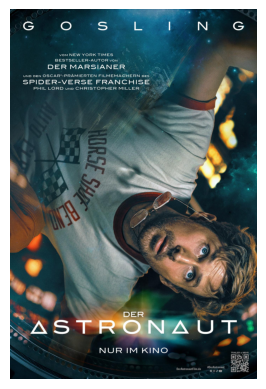

In [13]:
response = requests.get("https://api.imdbapi.dev/titles/tt12042730/images")
data = response.json()
url = data["images"][0]["url"]
img = mpimg.imread(BytesIO(requests.get(url).content), format="jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

In [15]:
plot = df[df["id"] == "tt12042730"]["plot"].values[0]
print(plot)

A science teacher wakes up alone on a spaceship. As his memory returns, he uncovers a mission to stop a mysterious substance killing Earth's sun and that an unexpected friendship may be the key.


## P4
> Discuss briefly the steps you would take to make sure your analysis is reproducible and easy to evaluate by others, even if the dataset is updated later.

Since our primary data source is an API, the database state doesn't affect reproducibility as long as we avoid hard-coding anything. The main reproducibility concern is the modeling environment, which depends on specific libraries like `scikit-learn`.

To solve this, we dockerize the project. Docker lets us package the app and its dependencies into a self-contained unit that runs identically anywhere. The process is straightforward: create a Dockerfile that defines the base environment, sets a working directory, installs dependencies from requirements.txt, exposes a port, and specifies the command to start the app. Once written, you build it into an image, which is a static blueprint, then run it as a container, which is a live instance of that image.

Think of the image as a recipe and the container as the dish. You can spin up as many containers from the same image as needed, and each one behaves the same way. This makes the entire pipeline from data fetching to modeling easy to share and replicate across any machine.